## Data Feeds
Quick reference for what's available through OpenBB — what each endpoint returns and whether it's worth wiring into the strategy pipeline.

In [1]:
# Credentials (FRED - required for macroeconomic information)
from dotenv import load_dotenv
import os
load_dotenv()

# Data
import pandas as pd

pd.set_option("display.max_columns", None)

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("bright")

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "sans-serif",
    }
)

# Financial
from openbb import obb
obb.user.credentials.fred_api_key = os.getenv("FRED_API_KEY")

# Nicer printing
from rich import print
from rich.panel import Panel

# SEC filings
import requests
from bs4 import BeautifulSoup
from pathlib import Path
import re

# OpenBB Routers

## Commodity
- EIA crude inventory data — a surprise draw is typically bullish for energy names
- **TODO (strategy notebook):** test the signal across XOM, CVX, COP, XLE, XOM
- **TODO (strategy notebook):** DAL and UAL should move the opposite way — higher oil costs hurt airlines

In [2]:
df = obb.commodity.petroleum_status_report().to_dataframe()

crude = (
    df[df["symbol"] == "WCESTUS1"][["value"]]
    .rename(columns={"value": "crude_stocks_mbb"})
    .sort_index()
)

crude.tail()

,crude_stocks_mbb
date,
2026-03-20,456185.0
2026-03-27,461636.0
2026-04-03,464717.0
2026-04-10,463804.0
2026-04-17,465729.0


## Economy
Top-level regime indicators — these don't drive trades directly but they tell me what kind of market environment I'm in.

| Indicator | What it measures | Regime signal | TODO |
|---|---|---|---|
| Yield curve (10Y-2Y) | Gap between long and short treasury yields | Negative = recession warning; steep = expansion | Test GLD and IWM response at 6m, 12m, 18m lags post-inversion |
| Unemployment (UNRATE) | % of workforce unemployed and actively looking for work | Rising fast = reduce risk; low and stable = risk-on | Implement Sahm Rule trigger and test as portfolio exit signal |
| PCE inflation | Fed's preferred price gauge across all consumer spending | Above 3% = favour value/energy; below 2% = favour growth | Classify PCE regimes and measure forward returns per sector |
| M2 money supply | Total money in circulation (cash, savings, money market) | Growing fast = liquidity rally; shrinking = tighten up | Test whether negative M2 YoY growth predicts equity drawdowns |
| OECD CLI | Forward-looking composite designed to call turning points 6-9 months early | Crossing above 100 = expansion; below 100 = slowdown | Test CLI crossings as entry/exit signal for cyclicals vs defensives |

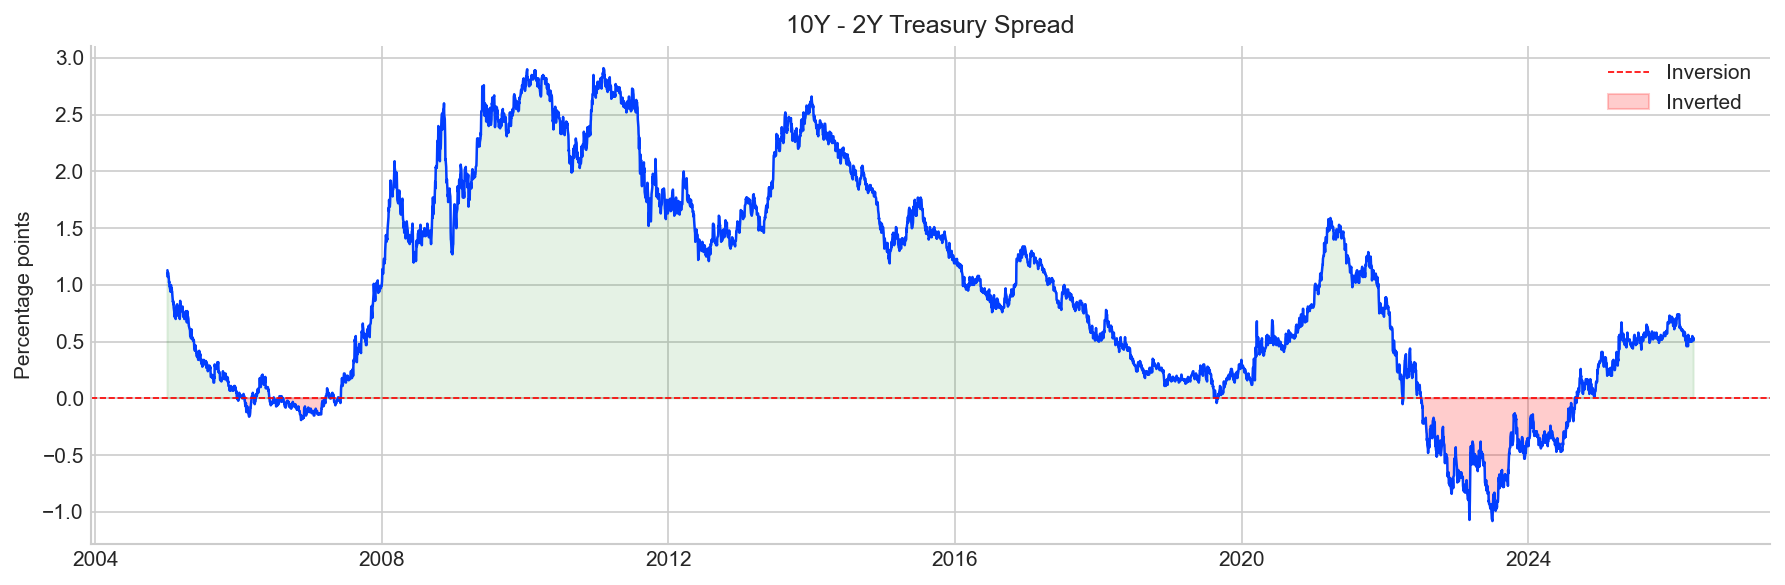

In [3]:
# TODO: Test as a signal for recession warning, impact on flight to safety assets on a potentially lagged basis
spread = (
    obb.economy.fred_series(symbol="T10Y2Y", start_date="2005-01-01")
    .to_dataframe()
    .rename(columns={"T10Y2Y": "value"})
)
spread.index = pd.to_datetime(spread.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(spread.index, spread["value"], linewidth=1.2)
ax.axhline(0, color="red", linewidth=0.8, linestyle="--", label="Inversion")
ax.fill_between(
    spread.index, spread["value"], 0,
    where=spread["value"] < 0, color="red", alpha=0.2, label="Inverted",
)
ax.fill_between(
    spread.index, spread["value"], 0,
    where=spread["value"] >= 0, color="green", alpha=0.1,
)
ax.set_title("10Y - 2Y Treasury Spread")
ax.set_ylabel("Percentage points")
ax.legend()
plt.tight_layout()

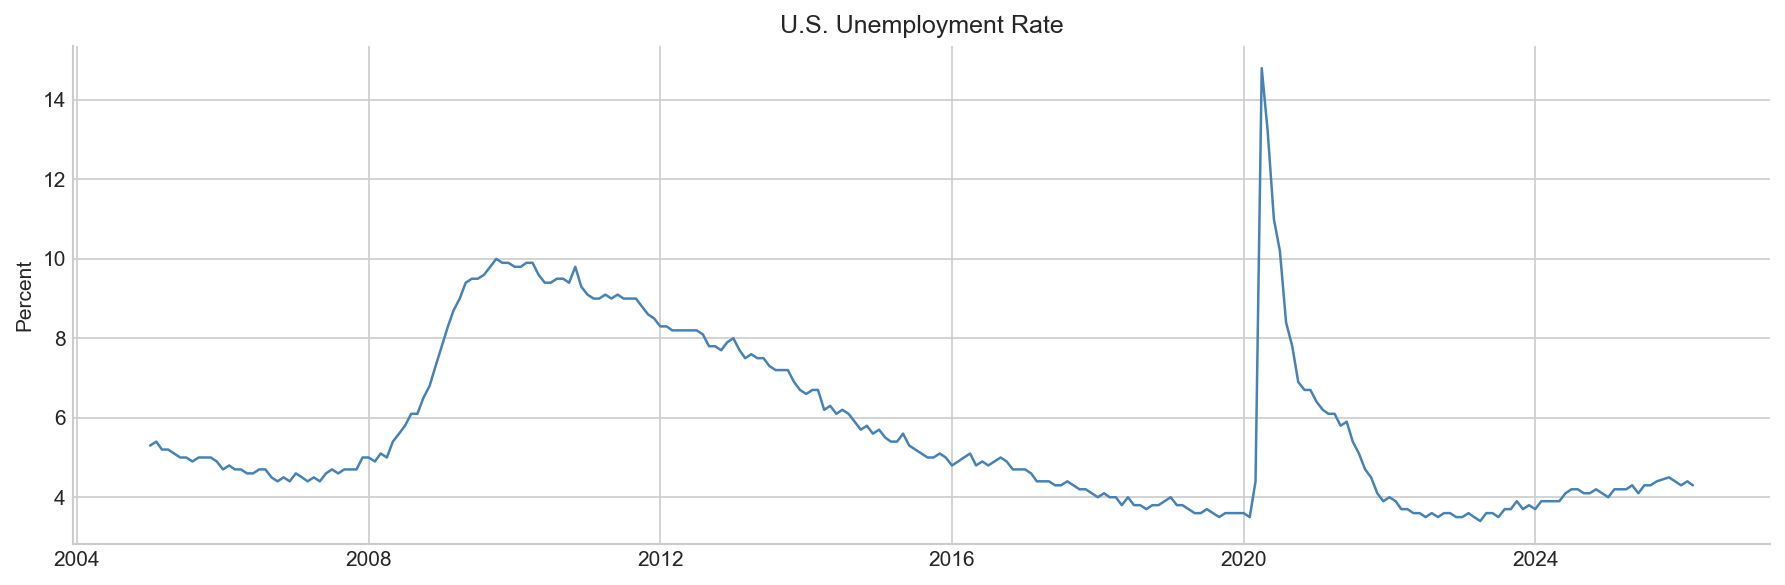

In [4]:
# TODO: Rising unemployment by 0.5% from its 12-month low (Sahm Rule) as a signal?
unemp = (
    obb.economy.fred_series(symbol="UNRATE", start_date="2005-01-01")
    .to_dataframe()
    .rename(columns={"UNRATE": "value"})
)
unemp.index = pd.to_datetime(unemp.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(unemp.index, unemp["value"], linewidth=1.2, color="steelblue")
ax.set_title("U.S. Unemployment Rate")
ax.set_ylabel("Percent")
plt.tight_layout()

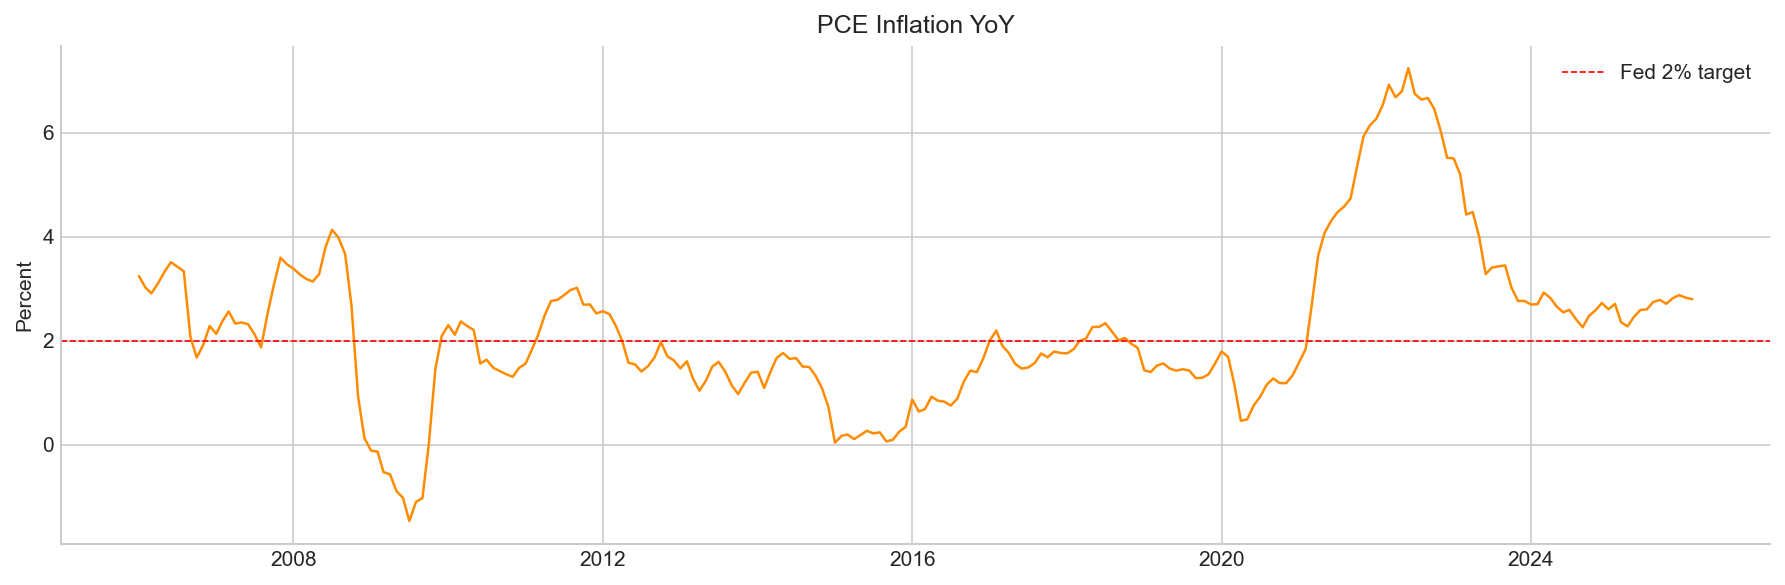

In [5]:
# TODO: Test PCE as a potential signal for risk-on vs risk-off
pce = (
    obb.economy.fred_series(symbol="PCEPI", start_date="2005-01-01")
    .to_dataframe()
    .rename(columns={"PCEPI": "value"})
)
pce.index = pd.to_datetime(pce.index)
pce["yoy"] = pce["value"].pct_change(12) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pce.index, pce["yoy"], linewidth=1.2, color="darkorange")
ax.axhline(2.0, color="red", linewidth=0.8, linestyle="--", label="Fed 2% target")
ax.set_title("PCE Inflation YoY")
ax.set_ylabel("Percent")
ax.legend()
plt.tight_layout()

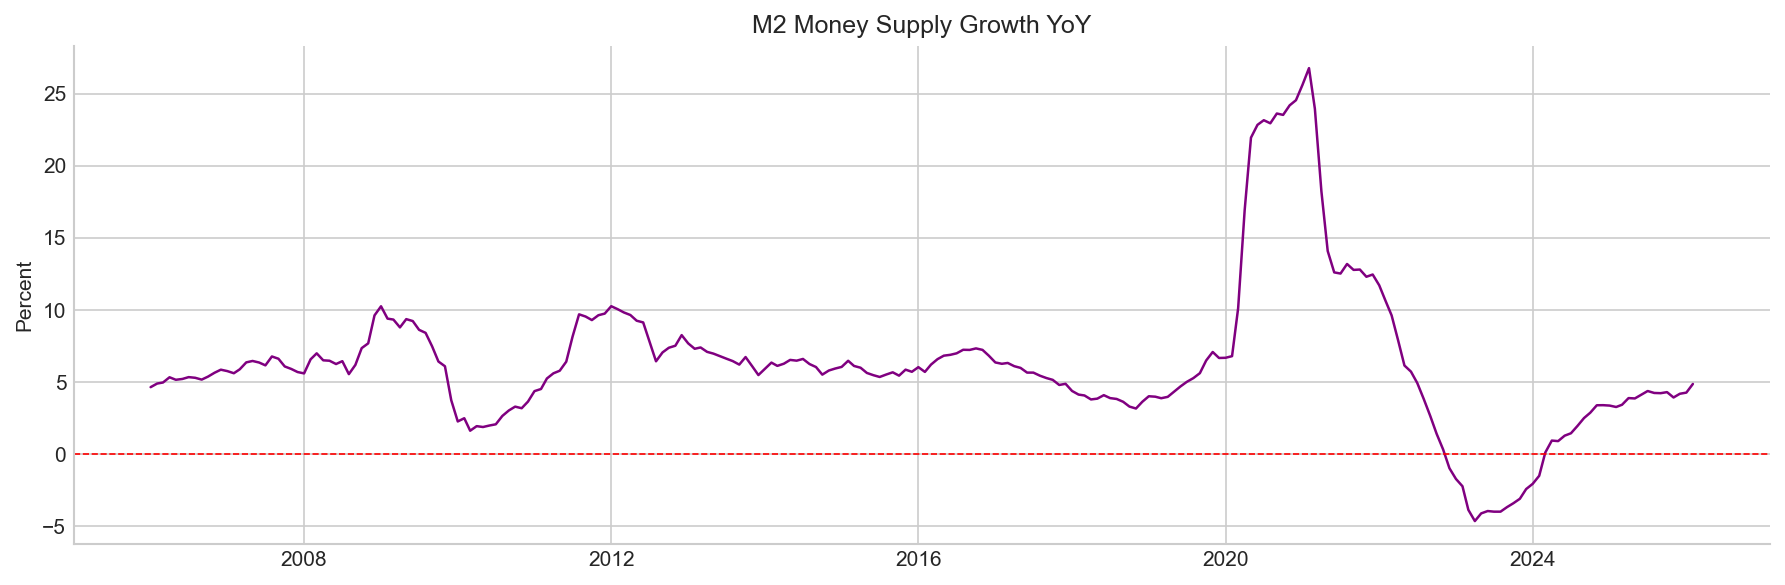

In [6]:
# TODO: Money supply's impact on equity buying vs. selling
m2 = (
    obb.economy.fred_series(symbol="M2SL", start_date="2005-01-01")
    .to_dataframe()
    .rename(columns={"M2SL": "value"})
)
m2.index = pd.to_datetime(m2.index)
m2["yoy"] = m2["value"].pct_change(12) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(m2.index, m2["yoy"], linewidth=1.2, color="purple")
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax.set_title("M2 Money Supply Growth YoY")
ax.set_ylabel("Percent")
plt.tight_layout()

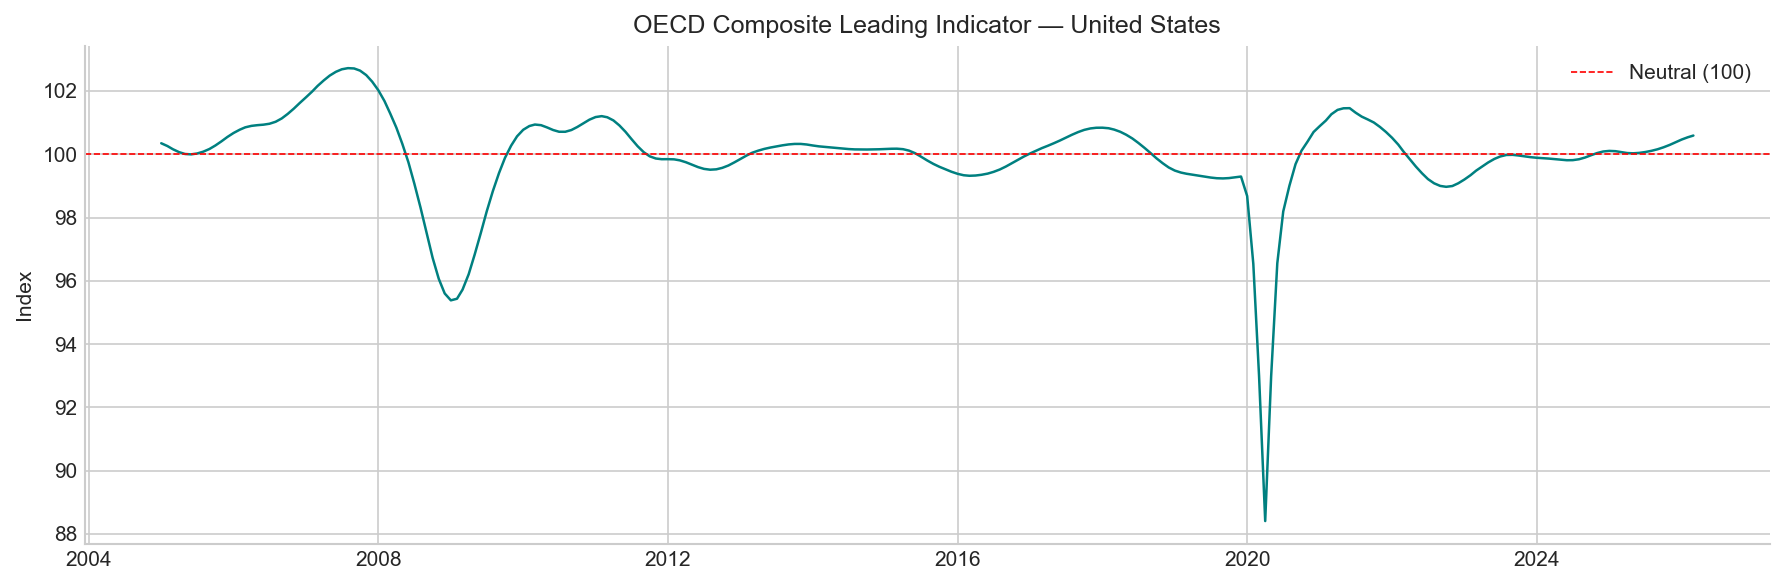

In [7]:
# TODO: CLI as an indicator for acceleration / deceleration and impact on equities
cli = obb.economy.composite_leading_indicator(start_date="2005-01-01").to_dataframe()
cli.index = pd.to_datetime(cli.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cli.index, cli["value"], linewidth=1.2, color="teal")
ax.axhline(100, color="red", linewidth=0.8, linestyle="--", label="Neutral (100)")
ax.set_title("OECD Composite Leading Indicator — United States")
ax.set_ylabel("Index")
ax.legend()
plt.tight_layout()

## Equity
### Stock Screener
- Get a working universe of US names, filtered by exchange, price floor, and top volume

In [8]:
US_EXCHANGES = {"NMS", "NGM", "NCM", "NYQ", "ASE"}

screener_obj = obb.equity.screener()
tickers = [s.symbol for s in screener_obj.results]
screener_df = obb.equity.screener().to_dataframe()
screener_df = screener_df[screener_df.exchange.isin(US_EXCHANGES)]

# price floor and top-volume cut
PRICE = 30
VOLUME_CAP = 30
screener_df = screener_df.query(f"price > {PRICE}").nlargest(VOLUME_CAP, columns="volume")
screener_df.sample(10)

,symbol,name,price,change,percent_change,volume,open,high,low,previous_close,ma50,ma200,year_high,year_low,market_cap,shares_outstanding,book_value,price_to_book,eps_ttm,eps_forward,pe_forward,dividend_yield,exchange,exchange_timezone,earnings_date,currency
83,SNDK,Sandisk Corporation,989.90,57.47000,0.061635,11545609,953.600,1002.0900,947.0001,932.43,715.870200,326.996030,1002.090,31.010,1.461102e+11,1.476010e+08,69.007000,14.344921,-7.42,114.38423,8.654165,0.000000,NMS,America/New_York,2026-04-30 16:00:00-04:00,USD
153,ENTG,"Entegris, Inc.",155.98,6.64999,0.044532,4314231,153.660,159.1500,151.1700,149.33,127.240400,100.069750,159.150,66.320,2.374778e+10,1.522489e+08,26.026000,5.993238,1.54,4.43009,35.209217,0.002679,NMS,America/New_York,2026-04-30 08:30:00-04:00,USD
154,WDAY,"Workday, Inc.",119.76,5.09000,0.044388,5468159,116.870,119.7700,114.3600,114.67,131.975400,198.366500,276.000,110.360,3.078419e+10,2.100000e+08,30.120000,3.976096,2.59,12.43784,9.628681,0.000000,NMS,America/New_York,2026-02-24 16:00:00-05:00,USD
57,XNDU,Xanadu Quantum Technologies Lim,30.95,2.10000,0.072790,3631931,32.000,34.8500,29.5000,28.85,15.734583,15.734583,42.440,6.970,1.051314e+10,4.328444e+07,NaN,NaN,-0.17,-0.53000,-58.396233,0.000000,NGM,America/New_York,NaN,USD
118,CRDO,Credo Technology Group Holding,195.04,9.50000,0.051202,6594511,188.130,198.9700,186.5700,185.54,122.555800,134.994780,213.800,40.175,3.597511e+10,1.844499e+08,10.036000,19.434036,1.81,5.44748,35.803707,0.000000,NMS,America/New_York,2026-03-02 16:00:00-05:00,USD
99,EW,Edwards Lifesciences Corporatio,84.15,4.43000,0.055569,11798864,82.500,84.7300,82.4725,79.72,81.615800,80.923850,87.890,72.300,4.851599e+10,5.765417e+08,17.802000,4.726997,1.81,3.35979,25.046207,0.000000,NYQ,America/New_York,2026-04-23 16:00:00-04:00,USD
37,HIMS,"Hims & Hers Health, Inc.",30.56,2.41000,0.085613,40409599,29.500,31.3298,28.9000,28.15,20.903000,37.890600,70.430,13.740,6.965809e+09,2.195611e+08,2.380000,12.840335,0.51,1.37932,22.155844,0.000000,NYQ,America/New_York,2026-05-11 16:00:00-04:00,USD
79,NOW,"ServiceNow, Inc.",90.17,5.39000,0.063576,35399154,85.780,90.3900,84.9500,84.78,104.880200,152.514080,211.478,81.240,9.299304e+10,1.031308e+09,12.379000,7.284110,1.68,5.00229,18.025745,0.000000,NYQ,America/New_York,2026-04-22 16:00:00-04:00,USD
13,AMD,"Advanced Micro Devices, Inc.",347.81,42.48000,0.139128,79942384,336.835,352.9900,334.5400,305.33,221.573800,206.595250,352.990,91.870,5.670732e+11,1.630339e+09,38.650000,8.998964,2.61,11.00824,31.595423,0.000000,NMS,America/New_York,2026-05-05 16:00:00-04:00,USD
114,TSM,Taiwan Semiconductor Manufactur,402.46,19.80000,0.051743,21544569,396.140,409.4900,393.8700,382.66,357.000200,301.368300,409.490,160.500,2.087319e+12,5.186400e+09,6.537354,61.563137,11.67,19.29218,20.861303,0.044426,NYQ,America/New_York,2026-04-16 08:30:00-04:00,USD


### Profile
- Sector and industry for tickers
- TODO: Determine the impact of macroeconomic regime on sectors

In [9]:
TICKERS = ["AAPL", "APLD", "COKE"]

profile = obb.equity.profile(symbol=TICKERS).to_dataframe()
profile

,symbol,name,stock_exchange,long_description,company_url,business_phone_no,hq_address1,hq_address_city,hq_address_postal_code,hq_state,hq_country,employees,sector,industry_category,issue_type,currency,market_cap,shares_outstanding,shares_float,shares_implied_outstanding,shares_short,beta,dividend_yield
0,APLD,Applied Digital Corporation,NMS,"Applied Digital Corporation designs, develops,...",https://applieddigital.com,214 427 1704,3811 Turtle Creek Boulevard,Dallas,75219,TX,United States,205,Technology,Information Technology Services,EQUITY,USD,9996218368,285769539,253829078,285769539,80062277,7.274,NaN
1,AAPL,Apple Inc.,NMS,"Apple Inc. designs, manufactures, and markets ...",https://www.apple.com,(408) 996-1010,One Apple Park Way,Cupertino,95014,CA,United States,150000,Technology,Consumer Electronics,EQUITY,USD,3979469914112,14681140000,14656035251,14681140000,134422787,1.109,0.38
2,COKE,"Coca-Cola Consolidated, Inc.",NMS,"Coca-Cola Consolidated, Inc., together with it...",https://www.cokeconsolidated.com,980 392 8298,4100 Coca-Cola Plaza,Charlotte,28211,NC,United States,15000,Consumer Defensive,Beverages - Non-Alcoholic,EQUITY,USD,13019310080,56517334,7951513,66564294,1561950,0.605,0.51


### Calendar
- TODO: Determine the impact of earnings date (pre, curr, post) on equity valuation

In [10]:
# screener can provide this info (otherwise fmp API key is needed for openbb.equity.calendar)
earnings_cal = (
    screener_df[["symbol", "name", "earnings_date"]]
    .dropna(subset=["earnings_date"])
    .sort_values("earnings_date")
)
earnings_cal.head(10)

,symbol,name,earnings_date
154,WDAY,"Workday, Inc.",2026-02-24 16:00:00-05:00
118,CRDO,Credo Technology Group Holding,2026-03-02 16:00:00-05:00
114,TSM,Taiwan Semiconductor Manufactur,2026-04-16 08:30:00-04:00
79,NOW,"ServiceNow, Inc.",2026-04-22 16:00:00-04:00
5,INTC,Intel Corporation,2026-04-23 16:00:00-04:00
99,EW,Edwards Lifesciences Corporatio,2026-04-23 16:00:00-04:00
67,BKR,Baker Hughes Company,2026-04-23 16:00:00-04:00
36,NEM,Newmont Corporation,2026-04-23 16:00:00-04:00
0,MXL,"MaxLinear, Inc",2026-04-23 16:00:00-04:00
12,RMBS,"Rambus, Inc.",2026-04-27 16:00:00-04:00


### Estimates
- Analyst expectations
- TODO: compute the surprise factor per ticker and potentially add it as a feature set

In [11]:
TICKERS = ["AAPL", "MSFT", "APLD", "COST", "NVDA"]

# analyst EPS consensus, target prices, and buy/sell/hold breakdown
estimates = obb.equity.estimates.consensus(symbol=TICKERS).to_dataframe()
estimates.head()

,symbol,target_high,target_low,target_consensus,target_median,recommendation,recommendation_mean,number_of_analysts,current_price,currency
0,APLD,97.0,36.0,52.81818,48.0,strong_buy,1.18182,11,34.98,USD
1,AAPL,350.0,215.0,297.70550,300.0,buy,1.89362,40,271.06,USD
2,COST,1315.0,650.0,1072.15620,1100.0,buy,1.97222,32,1011.15,USD
3,MSFT,730.0,392.0,576.42500,586.0,strong_buy,1.28571,54,424.62,USD
4,NVDA,380.0,140.0,268.61480,265.0,strong_buy,1.28814,56,208.27,USD


### Fundamental
- Income, balance sheet, and cash flow for value investing decisions
  - Find unicorns that are growing + solid fundamentals
- Ratios need an FMP key but the screener provides basic ratios, good enough for now
- TODO: build valuation factor features and test whether they predict forward returns

In [12]:
ratio_cols = ["symbol", "pe_forward", "price_to_book", "eps_ttm", "eps_forward", "dividend_yield"]
screener_df[ratio_cols].dropna(subset=["pe_forward"]).head(10)

,symbol,pe_forward,price_to_book,eps_ttm,eps_forward,dividend_yield
5,INTC,59.382580,3.606887,-0.60,1.389970,0.000000
162,NVDA,18.530712,32.180160,4.89,11.239180,0.000200
13,AMD,31.595423,8.998964,2.61,11.008240,0.000000
37,HIMS,22.155844,12.840335,0.51,1.379320,0.000000
79,NOW,18.025745,7.284110,1.68,5.002290,0.000000
0,MXL,35.454197,11.540080,-1.52,1.701350,0.000000
22,QCOM,13.510435,6.928735,4.96,11.017410,0.026278
70,NVO,12.008875,6.031642,3.61,3.428298,0.303738
114,TSM,20.861303,61.563137,11.67,19.292180,0.044426
10,ARM,109.514480,31.977394,0.75,2.144100,0.000000


In [13]:
# annual income statement — transposed so years are columns
TICKER = 'APLD'

income = obb.equity.fundamental.income(
    symbol=TICKER, period="annual", provider="yfinance"
).to_dataframe()

income.set_index("period_ending").T.sample(5)

period_ending,2025-05-31,2024-05-31,2023-05-31,2022-05-31,2021-05-31
operating_expense,83065000.0,45020000.0,53915000.0,19941000.0,NaN
other_income_expense,-103171000.0,-41517000.0,-94000.0,-936000.0,NaN
salaries_and_wages,NaN,NaN,NaN,12337000.0,0.0
gain_on_sale_of_ppe,23478000.0,-15417000.0,0.0,NaN,NaN
reconciled_cost_of_revenue,101451000.0,106653000.0,44388000.0,9506000.0,NaN


In [14]:
# annual balance sheet
balance = obb.equity.fundamental.balance(
    symbol=TICKER, period="annual", provider="yfinance"
).to_dataframe()

balance.set_index("period_ending").T.sample(5)

period_ending,2025-05-31,2024-05-31,2023-05-31,2022-05-31,2021-05-31
total_capitalization,1.311550e+09,204302000.0,127996000.0,78156000.0,NaN
long_term_debt_and_capital_lease_obligation,6.782210e+08,83925000.0,77818000.0,11207000.0,NaN
non_current_deferred_taxes_liabilities,NaN,NaN,0.0,540000.0,0.0
cash_and_cash_equivalents,4.155200e+07,3339000.0,28999000.0,38798000.0,NaN
current_deferred_liabilities,1.612500e+07,23556000.0,85062000.0,13401000.0,NaN


In [15]:
# annual cash flow statement
cashflow = obb.equity.fundamental.cash(
    symbol=TICKER, period="annual", provider="yfinance"
).to_dataframe()

cashflow.set_index("period_ending").T.sample(5)

period_ending,2025-05-31,2024-05-31,2023-05-31,2022-05-31,2021-05-31
issuance_of_common_equity,191590000.0,130849000.0,0.0,40000000.0,NaN
deferred_tax,0.0,0.0,-540000.0,540000.0,NaN
change_in_prepaid_assets,-7552000.0,-10132000.0,26079000.0,8193000.0,NaN
change_in_working_capital,-149381000.0,6068000.0,64691000.0,16810000.0,NaN
net_preferred_stock_issuance,198205000.0,0.0,0.0,34500000.0,NaN


### Discovery
- Pre-built screens for what's actively moving — a faster way to find names worth investigating
- TODO: test whether active/unusual names make better entry candidates for the golden cross

In [16]:
# what's up the most and down the most today
gainers = obb.equity.discovery.gainers(sort='desc').to_dataframe()
print("Gainers:")
display(gainers.head())

losers = obb.equity.discovery.losers(sort='desc').to_dataframe()
print("Losers:")
display(losers.head())

# most actively traded names right now
active = obb.equity.discovery.active().to_dataframe()
print("Actives:")
display(active.head())

# names that screen as undervalued — large cap and growth variants
undervalued_large = obb.equity.discovery.undervalued_large_caps().to_dataframe()
print("Undervalued Large:")
display(undervalued_large.head())

undervalued_growth = obb.equity.discovery.undervalued_growth().to_dataframe()
print("Undervalued Growth:")
display(undervalued_growth.head())

# tech names doing well
growth_tech = obb.equity.discovery.growth_tech().to_dataframe()
print("Growth Tech:")
display(growth_tech.head())

# aggressive small caps (likely more speculative)
aggressive_small = obb.equity.discovery.aggressive_small_caps().to_dataframe()
print("Aggressive Small Cap:")
display(aggressive_small.head())

Gainers:

,symbol,name,price,change,percent_change,volume,open,high,low,previous_close,ma50,ma200,year_high,year_low,market_cap,shares_outstanding,book_value,price_to_book,eps_ttm,eps_forward,pe_forward,dividend_yield,exchange,exchange_timezone,earnings_date,currency
0,MXL,"MaxLinear, Inc",60.32,26.07,0.761168,28696524,53.700,63.52,53.700,34.25,20.3174,17.482050,63.520,9.53,5.401412e+09,8.954596e+07,5.227,11.540080,-1.52,1.70135,35.454197,0.000000,NMS,America/New_York,2026-04-23 16:00:00-04:00,USD
1,IHRT,"iHeartMedia, Inc.",5.42,1.41,0.351621,532496,3.990,5.42,3.890,4.01,3.3013,3.176325,5.440,1.00,8.189319e+08,1.300043e+08,-11.802,-0.459244,-3.06,-0.39000,-13.897436,0.000000,NMS,America/New_York,2026-05-11 16:00:00-04:00,USD
2,OGN,Organon & Co.,11.26,2.66,0.309302,30139866,10.745,11.58,9.955,8.60,7.2254,8.359400,13.245,5.69,2.931154e+09,2.603156e+08,2.889,3.897543,0.72,3.68575,3.055009,0.039535,NYQ,America/New_York,2026-05-07 08:30:00-04:00,USD
3,SXT,Sensient Technologies Corporati,123.15,23.92,0.241056,1759042,108.470,124.00,104.990,99.23,92.9434,98.736150,124.000,82.60,5.240195e+09,4.255132e+07,28.236,4.361453,3.39,4.52801,27.197378,0.000000,NYQ,America/New_York,2026-04-24 08:30:00-04:00,USD
4,INTC,Intel Corporation,82.54,15.76,0.235999,279142137,82.130,85.22,79.620,66.78,51.0316,38.447900,85.220,18.97,4.148460e+11,5.026000e+09,22.884,3.606887,-0.60,1.38997,59.382580,0.000000,NMS,America/New_York,2026-04-23 16:00:00-04:00,USD


Losers:

,symbol,name,price,change,percent_change,volume,open,high,low,previous_close,ma50,ma200,year_high,year_low,market_cap,shares_outstanding,book_value,price_to_book,eps_ttm,eps_forward,pe_forward,dividend_yield,exchange,exchange_timezone,earnings_date,currency
0,OSK,Oshkosh Corporation (Holding Co,150.33,-2.75000,-0.017965,329022,152.47,154.510,149.80,153.08,155.11540,140.172000,180.49,82.140000,9.418052e+09,62649181.0,72.384,2.076840,10.03,14.23784,10.558484,0.013326,NYQ,America/New_York,2026-05-08 08:30:00-04:00,USD
1,DXCM,"DexCom, Inc.",61.57,-1.13000,-0.018022,3524944,62.68,62.900,60.34,62.70,66.87960,70.113400,89.98,54.110000,2.375820e+10,385872977.0,7.136,8.628082,2.09,2.99044,20.588943,0.000000,NMS,America/New_York,2026-04-30 16:00:00-04:00,USD
2,TXN,Texas Instruments Incorporated,277.14,-5.09000,-0.018035,13932652,287.83,287.830,272.01,282.23,209.64960,191.656250,287.83,152.730000,2.521974e+11,910000000.0,18.437,15.031731,5.85,9.13906,30.324783,0.019700,NMS,America/New_York,2026-04-22 16:00:00-04:00,USD
3,TR,"Tootsie Roll Industries, Inc.",41.84,-0.77000,-0.018071,74621,42.43,43.025,41.38,42.61,41.94814,38.814266,45.06,30.262136,3.145373e+09,43077605.0,12.535,3.337854,1.33,-1.95000,-21.456410,0.008144,NYQ,America/New_York,NaN,USD
4,CNR,"Core Natural Resources, Inc.",85.80,-1.57999,-0.018082,474611,86.42,87.170,84.85,87.38,94.49580,85.986900,114.80,63.360000,4.354382e+09,50750366.0,72.157,1.189074,-2.98,7.69500,11.150098,0.004578,NYQ,America/New_York,2026-05-07 08:30:00-04:00,USD


Actives:

...

,symbol,name,price,change,percent_change,volume,open,high,low,previous_close,ma50,ma200,year_high,year_low,market_cap,shares_outstanding,book_value,price_to_book,eps_ttm,eps_forward,pe_forward,dividend_yield,exchange,exchange_timezone,earnings_date,currency
0,UVE,UNIVERSAL INSURANCE HOLDINGS IN,39.48,4.30,0.122229,467910,37.50,39.53,35.8457,35.18,34.0088,30.099950,39.53,21.96,1.101689e+09,2.790500e+07,19.674,2.006709,6.76,4.00000,9.870000,0.018192,NYQ,America/New_York,2026-04-23 16:00:00-04:00,USD
1,NEM,Newmont Corporation,120.70,9.64,0.086800,10014952,115.01,120.83,111.6600,111.06,114.7680,94.411750,134.88,48.27,1.288536e+11,1.067553e+09,32.550,3.708141,7.71,10.95493,11.017870,0.009184,NYQ,America/New_York,2026-04-23 16:00:00-04:00,USD
2,KALU,Kaiser Aluminum Corporation,177.86,13.02,0.078986,447502,166.84,181.47,166.8400,164.84,131.6276,104.334500,181.47,60.22,2.906340e+09,1.634061e+07,51.438,3.457755,9.18,9.69433,18.346806,0.018685,NMS,America/New_York,2026-04-22 16:00:00-04:00,USD
3,AVAL,Grupo Aval Acciones y Valores S,4.62,0.25,0.057208,346634,4.32,4.64,4.3350,4.37,4.3030,3.908050,5.28,2.61,5.484743e+09,3.782931e+08,775.421,0.005958,0.39,0.53887,8.573497,0.000000,NYQ,America/New_York,2026-05-12 16:00:00-04:00,USD
4,TIGR,UP Fintech Holding Limited,6.94,0.34,0.051515,2359508,6.69,6.96,6.6700,6.60,7.1646,9.260675,13.55,5.95,1.238937e+09,1.720137e+08,4.867,1.425930,0.93,1.15153,6.026764,0.000000,NMS,America/New_York,2026-03-19 08:30:00-04:00,USD


Growth Tech:

,symbol,name,price,change,percent_change,volume,open,high,low,previous_close,ma50,ma200,year_high,year_low,market_cap,shares_outstanding,book_value,price_to_book,eps_ttm,eps_forward,pe_forward,dividend_yield,exchange,exchange_timezone,earnings_date,currency
0,AMD,"Advanced Micro Devices, Inc.",347.81,42.48,0.139128,79942384,336.835,352.990,334.540,305.33,221.5738,206.59525,352.99,91.870,5.670732e+11,1.630339e+09,38.650000,8.998964,2.61,11.00824,31.595423,0.000000,NMS,America/New_York,2026-05-05 16:00:00-04:00,USD
1,SIMO,Silicon Motion Technology Corpo,153.46,11.46,0.080704,725335,146.940,153.790,142.100,142.00,127.1458,100.74055,153.79,43.570,5.215135e+09,3.398367e+07,24.753000,6.199653,3.64,6.89123,22.268885,0.014085,NMS,America/New_York,2026-04-28 16:00:00-04:00,USD
2,TSM,Taiwan Semiconductor Manufactur,402.46,19.80,0.051743,21544569,396.140,409.490,393.870,382.66,357.0002,301.36830,409.49,160.500,2.087319e+12,5.186400e+09,6.537354,61.563137,11.67,19.29218,20.861303,0.044426,NYQ,America/New_York,2026-04-16 08:30:00-04:00,USD
3,CRDO,Credo Technology Group Holding,195.04,9.50,0.051202,6594511,188.130,198.970,186.570,185.54,122.5558,134.99478,213.80,40.175,3.597511e+10,1.844499e+08,10.036000,19.434036,1.81,5.44748,35.803707,0.000000,NMS,America/New_York,2026-03-02 16:00:00-05:00,USD
4,CLS,"Celestica, Inc.",410.21,18.61,0.047523,1966787,405.000,420.625,403.205,391.60,305.1322,275.23795,420.63,81.880,4.716151e+10,1.149692e+08,19.288000,21.267628,7.18,13.00026,31.553984,0.000000,NYQ,America/New_York,2026-04-27 16:00:00-04:00,USD


Aggressive Small Cap:

,symbol,name,price,change,percent_change,volume,open,high,low,previous_close,ma50,ma200,year_high,year_low,market_cap,shares_outstanding,book_value,price_to_book,eps_ttm,eps_forward,pe_forward,dividend_yield,exchange,exchange_timezone,earnings_date,currency
0,UVE,UNIVERSAL INSURANCE HOLDINGS IN,39.48,4.30,0.122229,467910,37.50,39.5300,35.8457,35.18,34.0088,30.09995,39.53,21.96,1.101689e+09,27905000.0,19.674,2.006709,6.76,4.00000,9.870000,0.018192,NYQ,America/New_York,2026-04-23 16:00:00-04:00,USD
1,AOSL,Alpha and Omega Semiconductor L,44.45,4.57,0.114594,1615275,42.69,45.9699,40.9000,39.88,24.7296,24.88015,45.97,17.01,1.322869e+09,29760825.0,27.678,1.605969,-3.51,-0.47333,-93.909120,0.000000,NMS,America/New_York,2026-05-06 16:00:00-04:00,USD
2,COOK,"Traeger, Inc.",38.86,3.95,0.113148,17456,35.18,39.8300,37.7800,34.91,35.2832,53.18480,110.50,20.91,1.066719e+08,2745030.0,62.322,0.623536,-43.50,3.46750,11.206922,0.000000,NYQ,America/New_York,2026-03-05 16:00:00-05:00,USD
3,CWH,"Camping World Holdings, Inc.",7.48,0.58,0.084058,7415664,7.00,7.5250,6.8000,6.90,7.8078,12.63060,19.64,5.70,4.751280e+08,63519784.0,3.603,2.076048,-1.43,1.04483,7.159059,0.072464,NYQ,America/New_York,2026-04-29 16:00:00-04:00,USD
4,HTLD,"Heartland Express, Inc.",13.03,1.01,0.084027,891758,12.50,13.2100,12.2600,12.02,10.7586,9.27675,13.21,7.00,1.009238e+09,77454920.0,9.753,1.335999,-0.67,0.45836,28.427437,0.006656,NMS,America/New_York,2026-04-23 08:30:00-04:00,USD


### Price
- Open / High / Low / Close - By ticker
- TODO: wire `price.historical()` into the backtesting engine as the price feed

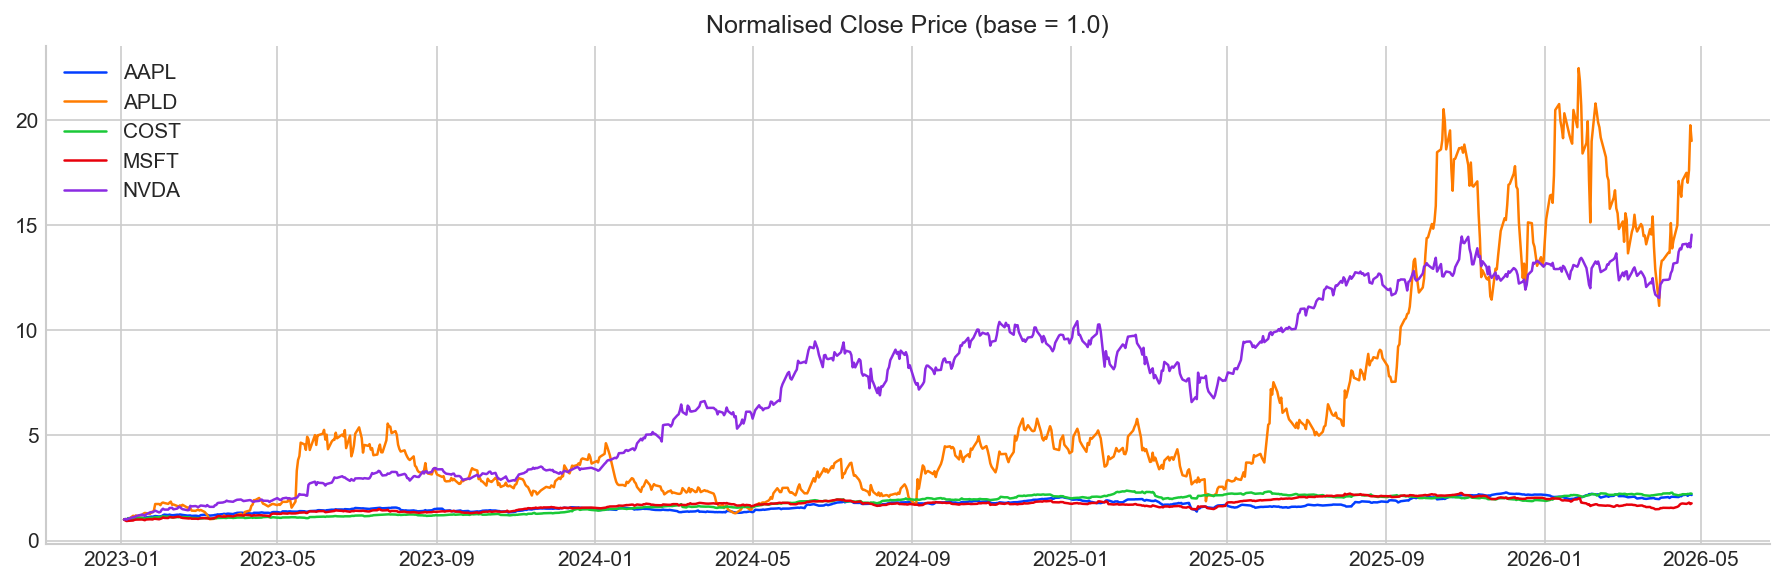

In [17]:
# normalise to 1.0 so performance for comparability
TICKERS = ["AAPL", "MSFT", "APLD", "COST", "NVDA"]

prices = obb.equity.price.historical(
    symbol=TICKERS, start_date="2023-01-01", provider="yfinance"
).to_dataframe()
prices.index = pd.to_datetime(prices.index)

fig, ax = plt.subplots(figsize=(12, 4))
for ticker, group in prices.groupby("symbol"):
    ax.plot(group.index, group["close"] / group["close"].iloc[0], linewidth=1.2, label=ticker)
ax.set_title("Normalised Close Price (base = 1.0)")
ax.legend()
plt.tight_layout()

In [18]:
# current price, change, and volume
quote = obb.equity.price.quote(symbol=TICKERS, provider="yfinance").to_dataframe()
quote

,symbol,asset_type,name,exchange,bid,bid_size,ask,ask_size,last_price,open,high,low,volume,prev_close,year_high,year_low,ma_50d,ma_200d,volume_average,volume_average_10d,currency
0,APLD,EQUITY,Applied Digital Corporation,NMS,34.91,37,35.10,34,34.98,37.500,38.54,34.82,35144939,36.35,42.27,4.20,28.5016,25.69520,22973464.0,27519280.0,USD
1,MSFT,EQUITY,Microsoft Corporation,NMS,424.03,2,424.76,2,424.62,416.985,424.89,415.80,27161742,415.75,555.45,356.28,394.0570,470.09515,37823058.0,36325510.0,USD
2,NVDA,EQUITY,NVIDIA Corporation,NMS,208.14,5,208.36,5,208.27,199.960,210.95,199.81,213442479,199.64,212.19,104.08,185.0252,182.84685,174659832.0,143680050.0,USD
3,COST,EQUITY,Costco Wholesale Corporation,NMS,1010.51,1,1011.21,1,1011.15,1010.980,1013.45,1002.50,1422495,1014.38,1067.08,844.06,996.8036,949.67080,1940054.0,1789260.0,USD
4,AAPL,EQUITY,Apple Inc.,NMS,266.00,1,286.63,1,271.06,272.760,273.06,269.67,38033227,273.43,288.62,193.25,260.1454,253.64070,45866346.0,44085150.0,USD


### Ownership
- Insider buys and sells via SEC EDGAR — executives buying their own stock is usually a good sign
- TODO: flag quarters with net insider buying as a feature in the ML model

In [19]:
# insider buys and sells from SEC filings
insider = obb.equity.ownership.insider_trading(symbol=TICKER, provider="sec").to_dataframe()
insider.head()


Found 13 total filings and 0 uncached entries to download, estimated download time: 0 seconds.



,symbol,company_cik,filing_date,transaction_date,owner_cik,owner_name,owner_title,ownership_type,transaction_type,acquisition_or_disposition,security_type,securities_owned,securities_transacted,filing_url,company_name,form,director,officer,ten_percent_owner,other,footnote,transaction_price,underlying_security_title,underlying_security_shares
0,APLD,0001144879,2026-04-14,2026-04-10,0001391935,Cummins Wes,CEO; Chairman,Direct,Exercise or conversion of derivative security ...,Acquisition,Common Stock,4341750.0,100000.0,https://www.sec.gov/Archives/edgar/data/114487...,Applied Digital Corp.,4,True,True,False,False,"Includes 742,166 shares held in the Report Per...",NaN,NaN,NaN
1,APLD,0001144879,2026-04-14,2026-04-10,0001391935,Cummins Wes,CEO; Chairman,Direct,Payment of exercise price or tax liability by ...,Disposition,Common Stock,4302400.0,39350.0,https://www.sec.gov/Archives/edgar/data/114487...,Applied Digital Corp.,4,True,True,False,False,"Includes 742,166 shares held in the Report Per...",26.26,NaN,NaN
2,APLD,0001144879,2026-04-14,2026-04-10,0001391935,Cummins Wes,CEO; Chairman,Direct,Exercise or conversion of derivative security ...,Disposition,Restricted Stock Unit,300000.0,100000.0,https://www.sec.gov/Archives/edgar/data/114487...,Applied Digital Corp.,4,True,True,False,False,NaN,0.00,Common Stock,100000.0
3,APLD,0001144879,2026-04-07,2026-04-04,0001391935,Cummins Wes,CEO; Chairman,Direct,Exercise or conversion of derivative security ...,Acquisition,Common Stock,4276329.0,100000.0,https://www.sec.gov/Archives/edgar/data/114487...,Applied Digital Corp.,4,True,True,False,False,"Includes 742,166 shares held in the Report Per...",NaN,NaN,NaN
4,APLD,0001144879,2026-04-07,2026-04-04,0001391935,Cummins Wes,CEO; Chairman,Direct,Payment of exercise price or tax liability by ...,Disposition,Common Stock,4241750.0,34579.0,https://www.sec.gov/Archives/edgar/data/114487...,Applied Digital Corp.,4,True,True,False,False,"Includes 742,166 shares held in the Report Per...",24.56,NaN,NaN


### Dividends
- Needed for proper total return calculations in the portfolio optimiser
- TODO: use ex-dividend dates to avoid noise from dividend mechanics in signal testing

In [20]:
# single ticker divident history (multiple require paid API)
TICKER = "COST"
dividends = obb.equity.fundamental.dividends(symbol=TICKER, provider="yfinance").to_dataframe()
dividends.tail()

,ex_dividend_date,amount
88,2025-02-07,1.16
89,2025-05-02,1.30
90,2025-08-01,1.30
91,2025-10-31,1.30
92,2026-01-30,1.30


## Fixed Income

| Endpoint | What it measures | Why it matters |
|---|---|---|
| Treasury rates | Historical yields at each maturity (2Y, 5Y, 10Y, 30Y) | Full term structure, not just the 2Y-10Y spread |
| Yield curve | Current shape snapshot | Steep vs inverted — the most-watched recession signal |
| EFFR | Fed funds effective rate over time | Where the Fed has actually set rates, historically |

,month_1,month_3,month_6,year_1,year_2,year_3,year_5,year_7,year_10,year_20,year_30
date,,,,,,,,,,,
2026-04-17,0.0369,0.0370,0.0369,0.0364,0.0371,0.0372,0.0384,0.0404,0.0426,0.0485,0.0488
2026-04-20,0.0369,0.0371,0.0372,0.0365,0.0372,0.0373,0.0386,0.0404,0.0426,0.0485,0.0488
2026-04-21,0.0367,0.0369,0.0373,0.0369,0.0378,0.0380,0.0391,0.0409,0.0430,0.0487,0.0489
2026-04-22,0.0368,0.0369,0.0372,0.0369,0.0379,0.0381,0.0391,0.0410,0.0430,0.0487,0.0490
2026-04-23,0.0369,0.0369,0.0372,0.0370,0.0383,0.0384,0.0396,0.0413,0.0434,0.0490,0.0492


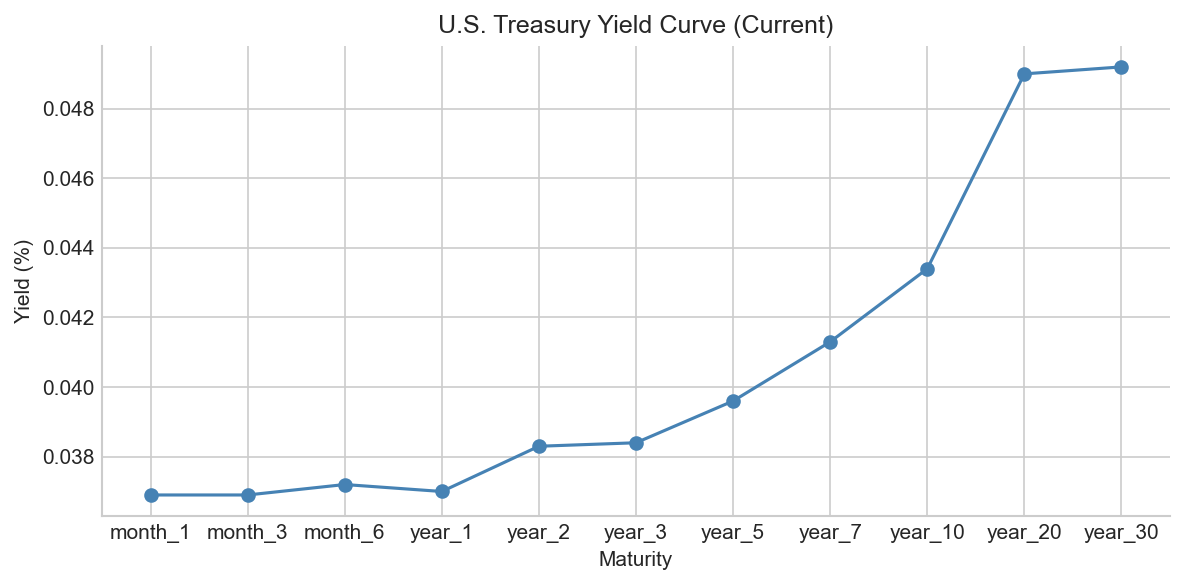

In [21]:
# rates at each maturity going back years
rates = obb.fixedincome.government.treasury_rates(provider="federal_reserve").to_dataframe()
display(rates.tail())

# is the curve inverted right now?
yc = obb.fixedincome.government.yield_curve(provider="federal_reserve").to_dataframe()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(yc["maturity"], yc["rate"], marker="o", linewidth=1.5, color="steelblue")
ax.set_title("U.S. Treasury Yield Curve (Current)")
ax.set_xlabel("Maturity")
ax.set_ylabel("Yield (%)")
plt.tight_layout()

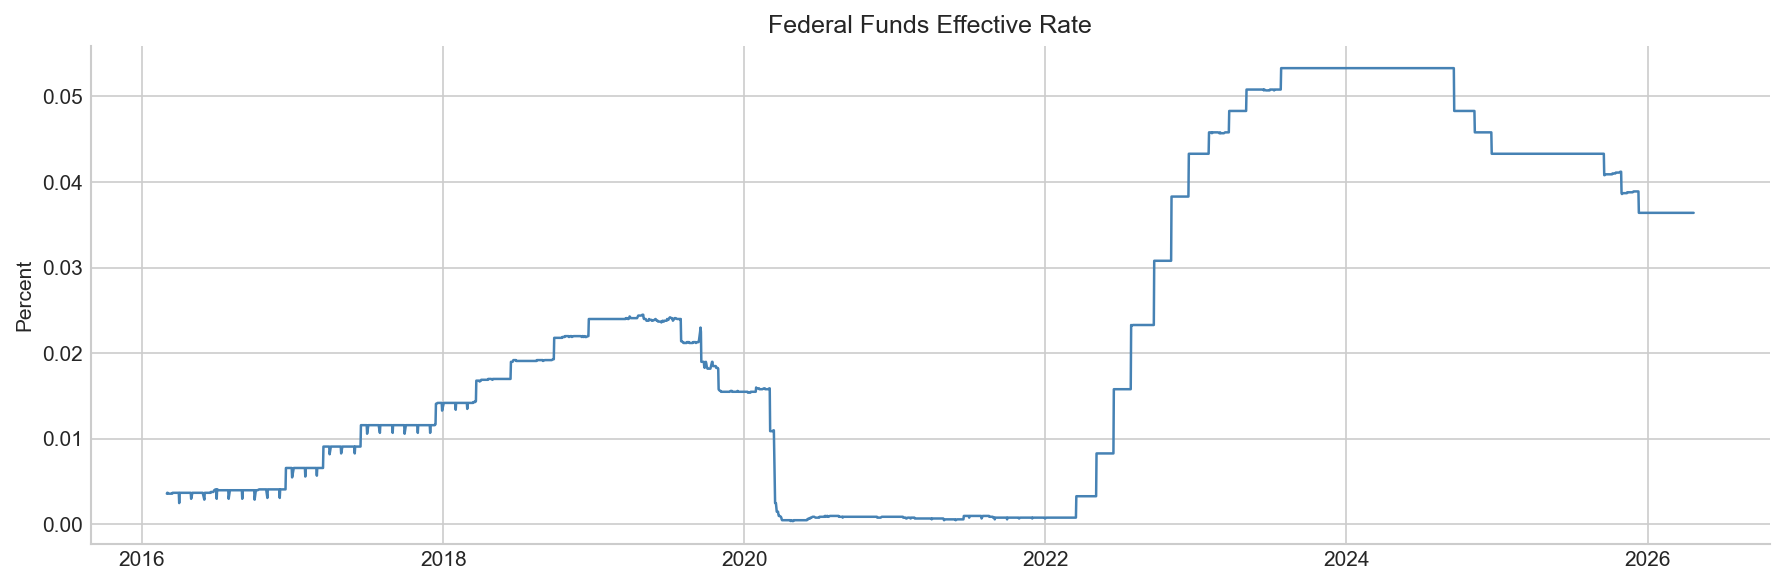

In [22]:
# where the Fed has set rates since 2005
effr = obb.fixedincome.rate.effr(start_date="2005-01-01", provider="fred").to_dataframe()
effr.index = pd.to_datetime(effr.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(effr.index, effr["rate"], linewidth=1.2, color="steelblue")
ax.set_title("Federal Funds Effective Rate")
ax.set_ylabel("Percent")
plt.tight_layout()

## Index
- VIX is the fear gauge — above 20 the market is nervous, above 30 it's usually in crisis mode
- Russell 2000 vs S&P 500 shows breadth — if only mega caps are running, the rally is fragile
- TODO: combine VIX level and yield curve slope to build a simple 4-quadrant regime label

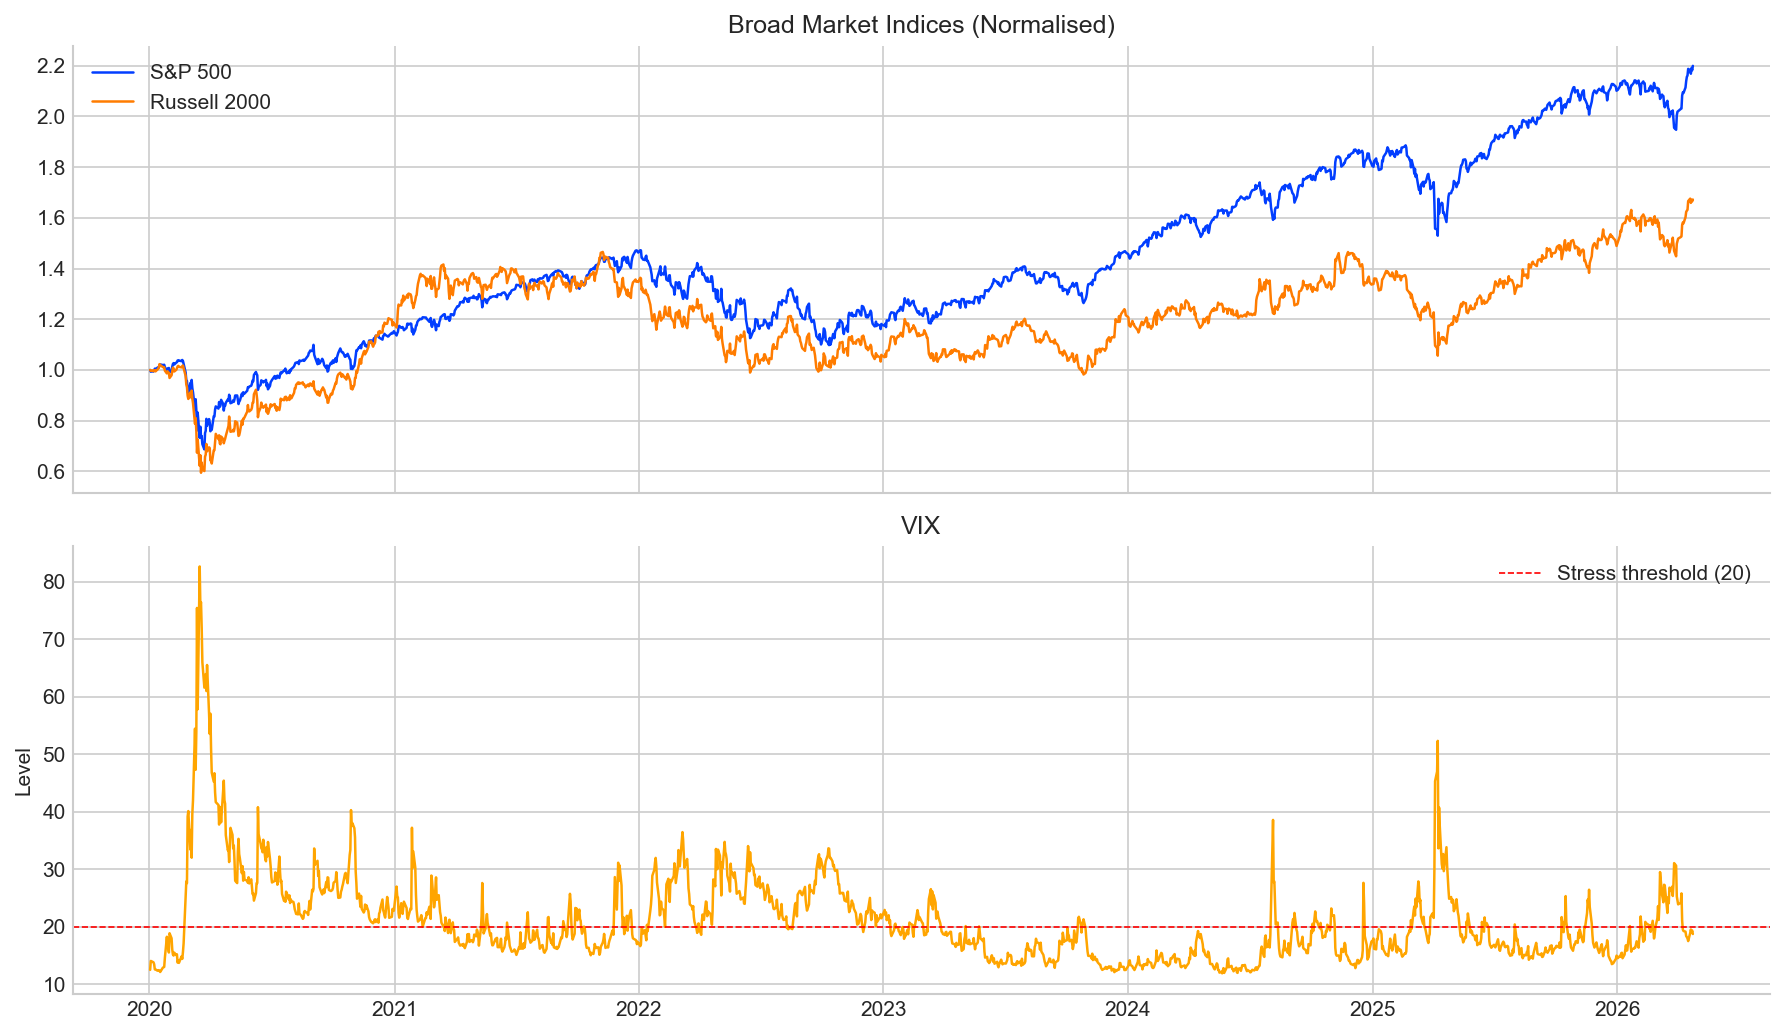

In [23]:
# broad market indices and the fear gauge
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for sym, label in [("^GSPC", "S&P 500"), ("^RUT", "Russell 2000")]:
    hist = obb.index.price.historical(
        symbol=sym, start_date="2020-01-01", provider="yfinance"
    ).to_dataframe()
    hist.index = pd.to_datetime(hist.index)
    axes[0].plot(hist.index, hist["close"] / hist["close"].iloc[0], linewidth=1.2, label=label)

vix = obb.index.price.historical(
    symbol="^VIX", start_date="2020-01-01", provider="yfinance"
).to_dataframe()
vix.index = pd.to_datetime(vix.index)
axes[1].plot(vix.index, vix["close"], linewidth=1.2, color="orange")
axes[1].axhline(20, color="red", linewidth=0.8, linestyle="--", label="Stress threshold (20)")

axes[0].set_title("Broad Market Indices (Normalised)")
axes[0].legend()
axes[1].set_title("VIX")
axes[1].set_ylabel("Level")
axes[1].legend()
plt.tight_layout()

## Currency
- TODO: Test the impact of a strong dollar on domestic and international tickers

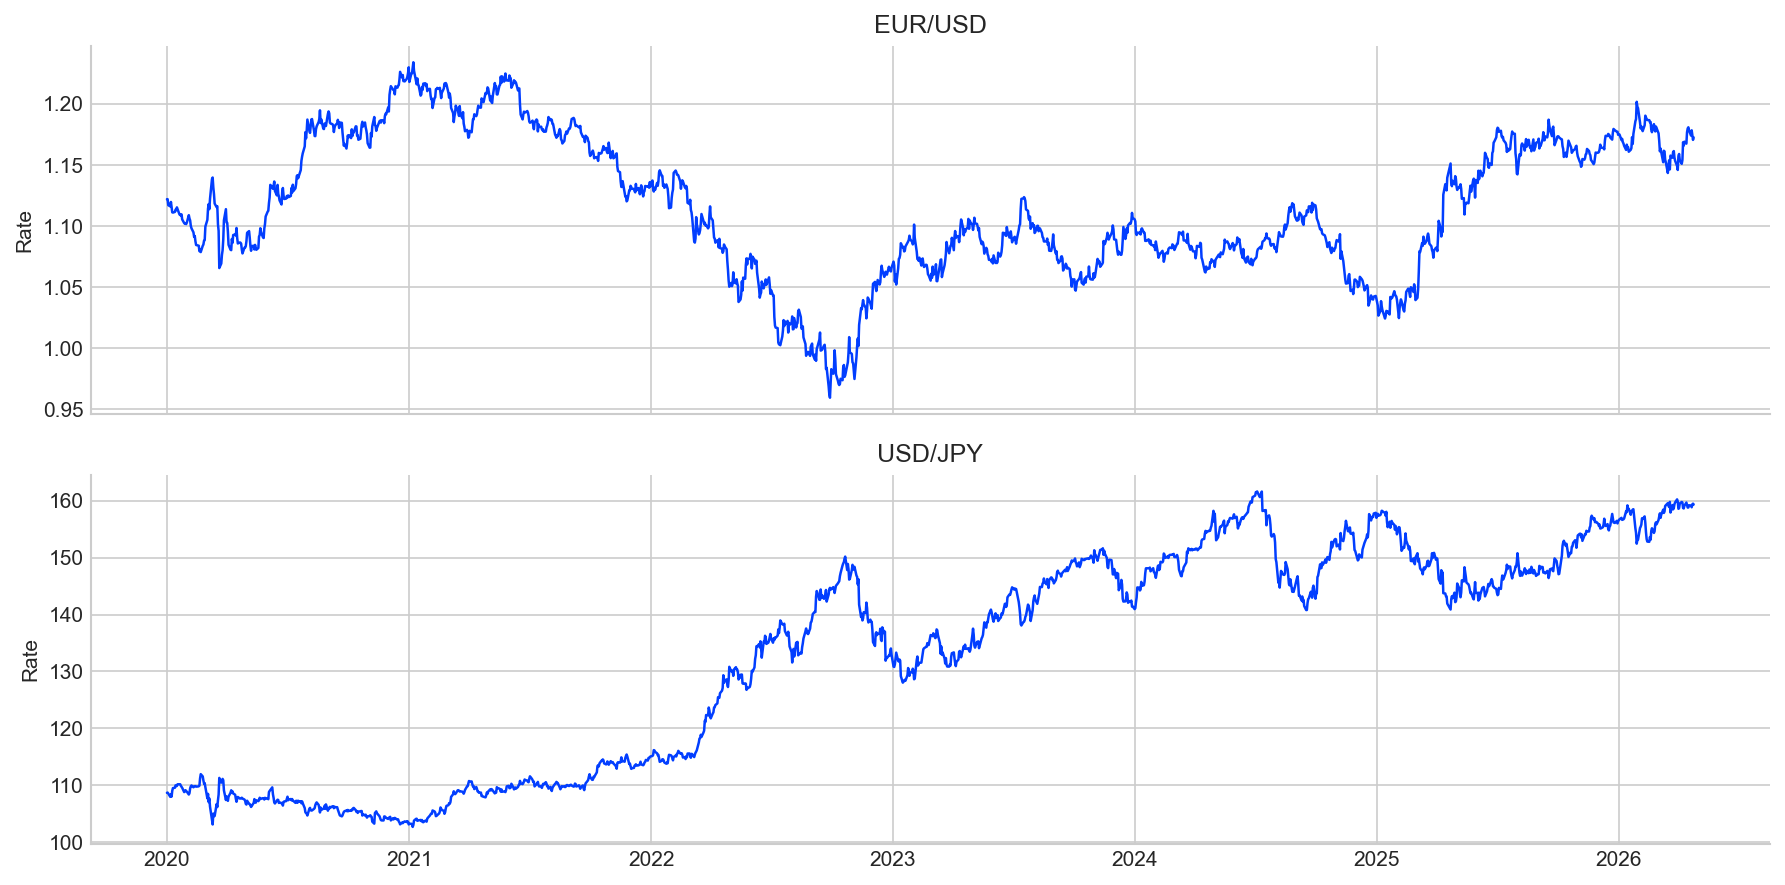

In [24]:
# major FX pairs — EUR/USD and USD/JPY as macro risk proxies
FX_PAIRS = [("EURUSD=X", "EUR/USD"), ("USDJPY=X", "USD/JPY")]

fig, axes = plt.subplots(len(FX_PAIRS), 1, figsize=(12, 6), sharex=True)
for ax, (sym, label) in zip(axes, FX_PAIRS):
    fx = obb.currency.price.historical(
        symbol=sym, start_date="2020-01-01", provider="yfinance"
    ).to_dataframe()
    fx.index = pd.to_datetime(fx.index)
    ax.plot(fx.index, fx["close"], linewidth=1.2)
    ax.set_title(label)
    ax.set_ylabel("Rate")

plt.tight_layout()

## News
- TODO: pipe headlines through Spacy / FinBERT / Claude, compute a daily sentiment score per ticker, and add it as a feature

In [25]:
news = obb.news.company(symbol=TICKER).to_dataframe()
news.sample(2)

,title,url,source,symbol,summary,text,id
date,,,,,,,
2026-04-24 18:47:00+00:00,Kroger quietly builds a massive gas edge over ...,https://finance.yahoo.com/sectors/energy/artic...,TheStreet,COST,"With gas prices skyrocketing, many consumers h...","With gas prices skyrocketing, many consumers h...",4dba4ccc-e548-382d-b5bb-52ccb2d841bf
2026-04-25 14:40:33+00:00,3 Stocks Announcing Dividend Hikes of 11% or More,https://finance.yahoo.com/markets/stocks/artic...,24/7 Wall St.,COST,Ever wonder why some portfolios keep deliverin...,Ever wonder why some portfolios keep deliverin...,3edfac31-242a-36a8-9da7-e8a8ab489438


# SEC Filings
- Explore filings as a potential data point for sentiment scoring signal

In [26]:
# map ticker to EDGAR CIK
cik_result = obb.regulators.sec.cik_map(symbol=TICKER).results
cik_padded = str(cik_result.cik).zfill(10)

# fetch filing index
url = f"https://data.sec.gov/submissions/CIK{cik_padded}.json"
data = requests.get(url, headers={"User-Agent": "research@example.com"}).json()
recent = pd.DataFrame(data["filings"]["recent"])

# show what's available
eightk = recent[recent["form"] == "8-K"][["filingDate", "primaryDocDescription"]].head(5)
annual_quarterly = recent[recent["form"].isin(["10-K", "10-Q"])][["form", "filingDate", "primaryDocDescription"]].head(5)

# fetch most recent 10-K
tenk = recent[recent["form"] == "10-K"].iloc[0]
accession = tenk["accessionNumber"].replace("-", "")
doc_url = f"https://www.sec.gov/Archives/edgar/data/{int(cik_padded)}/{accession}/{tenk['primaryDocument']}"
response = requests.get(doc_url, headers={"User-Agent": "research@example.com"})

soup = BeautifulSoup(response.text, "html.parser")
text = soup.get_text(separator="\n", strip=True)

# find all ITEM 7 / ITEM 8 positions, pick the pair with the most text between them
# (first occurrences is usually the TOC, skip)
pos7 = [m.start() for m in re.finditer(r"^\s*ITEM\s+7\b(?!\s*A)", text, re.IGNORECASE | re.MULTILINE)]
pos8 = [m.start() for m in re.finditer(r"^\s*ITEM\s+8\b", text, re.IGNORECASE | re.MULTILINE)]

mda = ""
for s in pos7:
    after = [e for e in pos8 if e > s]
    if after:
        candidate = text[s:after[0]].strip()
        if len(candidate) > len(mda):
            mda = candidate

# print out the md&a section
print(Panel(mda[:2000], title=f"{TICKER} MD&A"))

╭─────────────────────────────────────────────────── COST MD&A ───────────────────────────────────────────────────╮
│ Item 7—Management's Discussion and Analysis of Financial Condition and Results of Operations                    │
│ (amounts in millions, except per share, share, percentages and warehouse count data)                            │
│ Overview                                                                                                        │
│ Management's Discussion and Analysis of Financial Condition and Results of Operations (MD&A) is intended to     │
│ promote understanding of the results of operations and financial condition. MD&A is provided as a supplement    │
│ to, and should be read in conjunction with, our consolidated financial statements and the accompanying Notes to │
│ Financial Statements (Part II, Item 8 of this Form 10-K). This section generally discusses the results of       │
│ operations for 2025 compared to 2024. For discussion related to the results of operations and changes in        │
│ financial condition for 2024 compared to 2023 refer to Part II, Item 7, Management's Discussion and Analysis of │
│ Financial Condition and Results of Operations in our fiscal year 2024 Form 10-K, which was filed with the       │
│ Securities and Exchange Commission (SEC) on October 9, 2024.                                                    │
│ We believe that the most important driver of our profitability is increasing net sales, particularly comparable │
│ sales. Net sales includes our core merchandise categories (foods and sundries, non-foods, and fresh foods),     │
│ warehouse ancillary (gasoline, pharmacy, optical, food court, hearing aids, and tire installation) and other    │
│ businesses (e-commerce, business centers, travel, and other). E-commerce and business center sales are          │
│ allocated to the appropriate merchandise categories in the Net Sales discussion. The 2% reward associated with  │
│ Executive membership reduces net sales and is allocated to the category in which the reward is generated (core  │
│ merchandise categories, warehouse ancillary, and other businesses). Comparable sales is defined as net sales    │
│ from warehouses open for more than one year, including remodels, relocations and expansions, and sales related  │
│ to e-commerce sites operating for more than one year. The measure is intended as supplemental information and   │
│ is not a s                                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯